Text(0.5, 1.0, 'Euler Method for different step sizes')

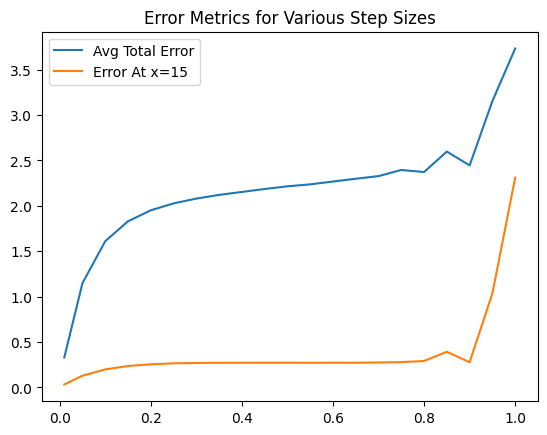

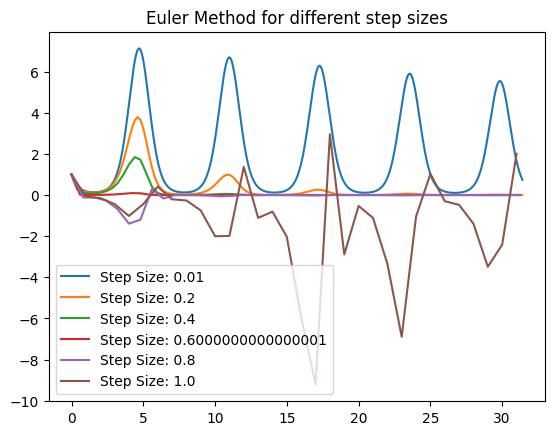

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import math 


step_sizes = np.arange(0,1.05, 0.05)
step_sizes[0] = 0.01

x_intervals = [np.arange(0, 10*np.pi, step) for step in step_sizes]

currYVal = 1
y_intervals = []
for x_interval in (x_intervals):
    y_intervals.append(np.zeros(len(x_interval)))

for i in range(len(x_intervals)):
    currYVal = 1
    y_intervals[i][0] = currYVal
    for j in range(1, len(x_intervals[i])):
        y_new = currYVal + -2*currYVal*np.cos(x_intervals[i][j])*step_sizes[i]
        y_intervals[i][j] = y_new
        currYVal = y_new


avgYVals = [y_interval.sum()/len(y_interval) for y_interval in y_intervals]

analyticYVals = [np.exp(-2*np.sin(x_interval)) for x_interval in x_intervals]



analyticInterpolations = []
eulerInterpolations = []


localErrorForAllRuns = []
totalErrorForAllRuns = [[0] for x_interval in x_intervals]

for i in range(len(x_intervals)):
    analyticInterpolations.append(CubicSpline(x_intervals[i], analyticYVals[i]))
    eulerInterpolations.append(CubicSpline(x_intervals[i], y_intervals[i]))

    # I can do this because len(x_intervals[i]) = len(y_intervals[i]) and len(x_intervals) = len(y_intervals)
    localErrorForAllRuns.append(abs(analyticYVals[i] - y_intervals[i]))

for i in range(len(x_intervals)):
    for j in range(1, len(x_intervals[i])):
        totalErrorForAllRuns[i].append(totalErrorForAllRuns[i][j-1] + localErrorForAllRuns[i][j-1])


# Had to google the zip operation lol
localEulerError15 = [abs(analyticInterpolation(15) - eulerInterpolation(15)) for analyticInterpolation, eulerInterpolation in zip(analyticInterpolations, eulerInterpolations)]


x_fine = np.linspace(0, 10*np.pi, 10000)

avgErrorForAllRuns = []
for i in range(len(x_intervals)):
    error = np.abs(analyticInterpolations[i](x_fine) - eulerInterpolations[i](x_fine))
    avgErrorForAllRuns.append(np.mean(error))    






plt.title('Error Metrics for Various Step Sizes')
plt.plot(step_sizes, avgErrorForAllRuns, label = ("Avg Total Error"))
plt.plot(step_sizes, localEulerError15, label = ("Error At x=15"))
plt.legend()


plt.figure()
for i in range(0, len(x_intervals), 4):
    plt.plot(x_intervals[i], y_intervals[i], label=("Step Size: "+ str(step_sizes[i])))


plt.legend()
plt.title('Euler Method for different step sizes')






1. It appears that the average total error seems to increase when we have larger step sizes, which makes sense.
2. It appears that the local error at x=15 also seems to increase when we have larger step sizes, which also makes sense.
3. It appears that the euler method for small step sizes looks smooth and continuous as opposed to larger step sizes.

![StabilityAnalysis](StabilityAnalysis.jpg)